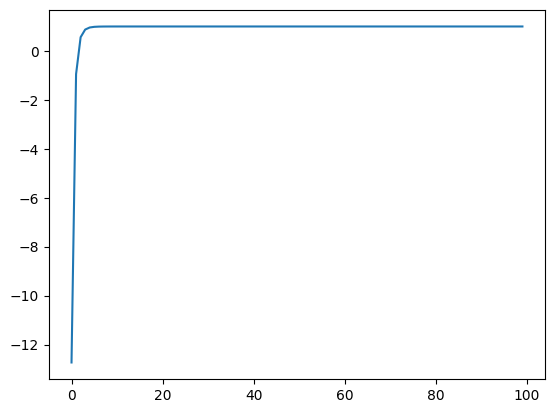

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

N = 10000 #경사하강법 반복횟수
alpha = 0.001 #학습률
alt = np.array([1, 2, 3]) #해발고도 리스트
grad = np.array([3, 7, 5]) #경사 리스트(각 x, dy/dx 기울기 o)
fatigue = np.array([1, 4, 9]) #피로도 리스트
v = np.array([3, 38, 15]) #속도 리스트

R2s = np.array([]) #결정계수 리스트

# 정규화
altnn = np.array([np.mean(alt), np.std(alt)])
gradnn = np.array([np.mean(grad), np.std(grad)])
fatiguenn = np.array([np.mean(fatigue), np.std(fatigue)])
vnn = np.array([np.mean(v), np.std(v)])

altN = (alt - altnn[0]) / altnn[1]
gradN = (grad - gradnn[0]) / gradnn[1]
fatigueN = (fatigue - fatiguenn[0]) / fatiguenn[1]
vN = (v - vnn[0]) / vnn[1]


# 다항함수 회귀
polynomialC = np.random.normal(0, 1, 10)
polynomialV = [altN**2, gradN**2, fatigueN**2, altN*gradN, gradN*fatigueN, fatigueN*altN, altN, gradN, fatigueN, np.ones(len(alt))] #DelCP역할

def polynomial(a, g, f):
    return np.dot(polynomialC, [a*a, g*g, f*f, a*g, g*f, f*a, a, g, f, 1])

def calcY():
    return [polynomial(altN[i], gradN[i], fatigueN[i]) for i in range(len(alt))]

#결정계수 계산
def R2():
    Y = calcY()
    ym = np.mean(vN)
    return 1 - (sum([(Y[i] - vN[i])**2 for i in range(len(alt))]))/(sum([(i - ym)**2 for i in Y]))

for _ in range(N): 
    deviation = np.array([polynomial(altN[i], gradN[i], fatigueN[i]) - vN[i] for i in range(len(alt))])
    DelCL = np.array([np.dot(deviation, polynomialV[i]) for i in range(10)])
    polynomialC -= alpha * DelCL
    if (_ + 1) % 100 == 0:
         R2s = np.append(R2s, R2())

def test(a, g, f):
    return(polynomial((a - altnn[0])/altnn[1], (g - gradnn[0])/gradnn[1], (f - fatiguenn[0])/fatiguenn[1])*vnn[1] + vnn[0])

plt.plot(np.arange(100), R2s)
plt.show()

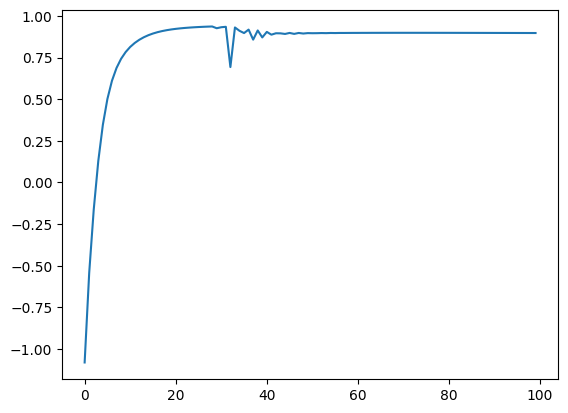

In [9]:
import numpy as np
from matplotlib import pyplot as plt

N = 10000 #경사하강법 반복횟수
alpha = 0.01 #학습률
alt = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) #해발고도 리스트
grad = np.array([3, 7, 5, 2, 3, 5, 1, 8, 3, 2]) #경사 리스트(각 x, dy/dx 기울기o)
fatigue = np.array([1, 4, 9, 2, 4, 6, 9, 2, 0, 9]) #피로도 리스트
v = np.array([3, 38, 15, 24, 30, 52, 23, 17, 3, 9]) #속도 리스트, 얘네들 싹다 손으로 작성...?

R2s = np.array([]) #결정계수 리스트

# 정규화 [0,1] 사이
altnn = np.array([np.min(alt), np.max(alt)-np.min(alt)])
gradnn = np.array([np.min(grad), np.max(grad)-np.min(grad)])
fatiguenn = np.array([np.min(fatigue), np.max(fatigue)-np.min(fatigue)])
vnn = np.array([np.min(v), np.max(v)-np.min(v)])

altN = (alt - altnn[0]) / altnn[1]
gradN = (grad - gradnn[0]) / gradnn[1]
fatigueN = (fatigue - fatiguenn[0]) / fatiguenn[1]
vN = (v - vnn[0]) / vnn[1]

#지수함수 회귀
exponentialC = np.random.normal(0, 1, 16)

def exponential(a, g, f):
    return (np.dot(exponentialC[0:4],[a, g, f, 1])*np.exp(exponentialC[4]*a)\
    + np.dot(exponentialC[5:9],[a, g, f, 1])*np.exp(exponentialC[9]*g)\
    + np.dot(exponentialC[10:14],[a, g, f, 1])*np.exp(exponentialC[14]*f)\
    + exponentialC[15])

def calcY():
    return [exponential(altN[i], gradN[i], fatigueN[i]) for i in range(len(alt))]

#결정계수 계산
def R2():
    Y = calcY()
    ym = np.mean(vN)
    return 1 - (sum([(Y[i] - vN[i])**2 for i in range(len(alt))]))/(sum([(i - ym)**2 for i in Y]))

#학습
for _ in range(N):
        a = altN
        g = gradN
        f = fatigueN
        ea = np.exp(exponentialC[4]*a)
        eg = np.exp(exponentialC[9]*g)
        ef = np.exp(exponentialC[14]*f)
        DelCP = [
            a*ea,
            g*ea,
            f*ea,
            ea,
            a*(exponentialC[0]*a + exponentialC[1]*g + exponentialC[2]*f + exponentialC[3])*ea,
            a*eg,
            g*eg,
            f*eg,
            eg,
            g*(exponentialC[5]*a + exponentialC[6]*g + exponentialC[7]*f + exponentialC[8])*eg,
            a*ef,
            g*ef,
            f*ef,
            ef,
            f*(exponentialC[10]*a + exponentialC[11]*g + exponentialC[12]*f + exponentialC[13])*ef,
            np.ones_like(alt)
         ]
        deviation = np.array([exponential(a[i], g[i], f[i]) - vN[i] for i in range(len(a))])
        DelCL = np.array([np.dot(deviation, DelCP[i]) for i in range(16)])
        exponentialC -= alpha * DelCL
        if (_ + 1) % 100 == 0:
             R2s = np.append(R2s, R2())
    

def test(a, g, f):
    return exponential((a - altnn[0])/altnn[1], (g - gradnn[0])/gradnn[1], (f - fatiguenn[0])/fatiguenn[1])*vnn[1] + vnn[0]

plt.plot(np.arange(100), R2s)
plt.show()